In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
df= pd.read_csv("C:/Users/Hanumakshi/Downloads/archive (8)/housing.csv")

In [25]:
print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [41]:
# Missing Values


print(df.isnull().sum())


longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


In [42]:
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)


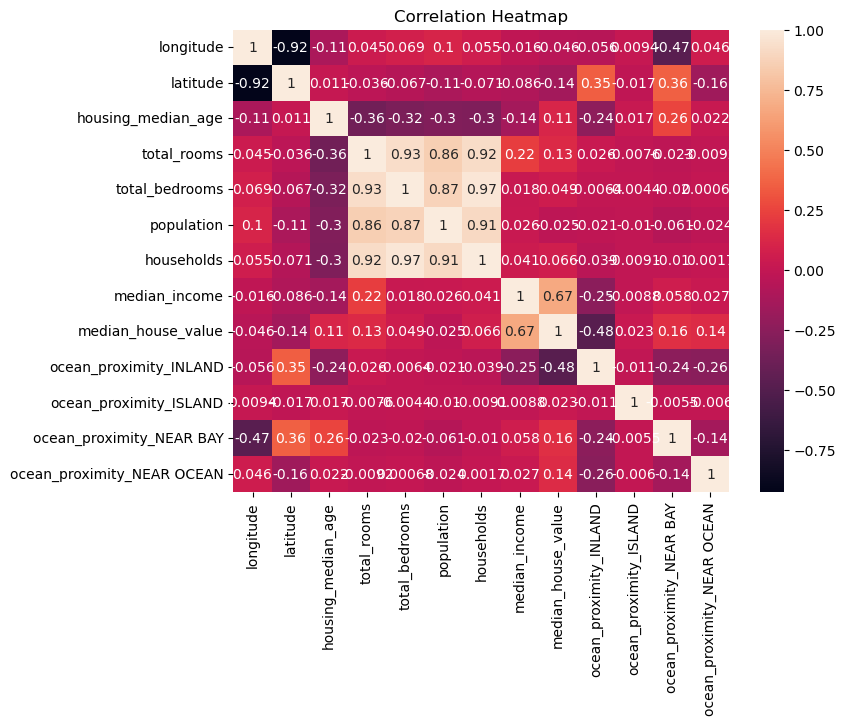

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()


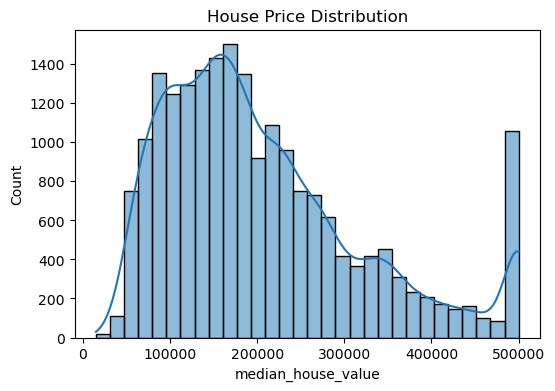

In [44]:
# House Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['median_house_value'], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

In [45]:
# Log Transformation
df['median_income'] = np.log1p(df['median_income'])


In [46]:
# Evaluate
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

R2 Score: 0.7609730483933395
Mean Squared Error: 3132230634.2692103


In [47]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [48]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')


In [ ]:
# One Hot Encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [ ]:
# Features and Target
# ====================================

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']


In [50]:
# Scaling

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [51]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

best_rmse = float('inf')
best_model = None


In [53]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)


Linear Regression
MAE : 54146.97653206642
RMSE: 72680.32403203787
R2 Score: 0.5968869574983238

Random Forest
MAE : 31670.248447189922
RMSE: 49024.3993809257
R2 Score: 0.8165922414629031

Gradient Boosting
MAE : 38357.07660303605
RMSE: 55966.33482969213
R2 Score: 0.7609730483933395


In [54]:
 # Residual Analysis
    residuals = y_test - y_pred

    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0, linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{name} Residual Analysis")
    plt.show()

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model

IndentationError: unexpected indent (2775167921.py, line 2)

In [ ]:
# Save Best Model

joblib.dump(best_model, "house_price_model.joblib")

print("\nBest Model Saved Successfully!")

# Example Prediction

loaded_model = joblib.load("house_price_model.joblib")

sample = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(sample)

print("\nPredicted House Price:", prediction[0])